# Assignment: Country Segmentation Analysis
**Course:** Machine Learning / Customer Intelligence  
**Submitted By:** Manthan  
**Date:** June 2026  

---

## Project Overview

This notebook contains my implementation for the country segmentation assignment using the Kaggle "Unsupervised Learning on Country Data" dataset. The goal is to analyze global socio-economic and health indicators to group countries into distinct categories. This helps identify different developmental tiers and highlights regions that require strategic humanitarian aid.

While applied to countries here, this workflow directly mirrors an industrial customer intelligence framework used to group users based on behavioral and financial attributes.

## Core Workflow

1. **Data Cleaning & Scaling:** Handled missing values, removed duplicates, and applied standardization via StandardScaler so that differing feature magnitudes do not distort distance calculations.
2. **Exploratory Analysis:** Used correlation heatmaps to assess feature relationships and boxplots to inspect distributions.
3. **K-Means Optimization:** Evaluated the optimal number of clusters using the Elbow Method across a range of 2 to 10 clusters.
4. **Comparative Clustering (DBSCAN):** Implemented a density-based algorithm to contrast against K-Means and isolate outliers or anomalous data points.
5. **PCA Visualization:** Applied Principal Component Analysis to reduce the high-dimensional data into two components for visual validation of the clusters.
6. **Cluster Profiling:** Aggregated the segmented data to build clear profiles for each group, leading to data-driven insights on aid prioritization.

## 1) Install required libraries

In [ ]:
# Installing core data science packages for preprocessing, clustering, and plotting
import subprocess
import sys

try:
    import sklearn
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"])

## 2) Import libraries

In [ ]:
# Import all required scientific computing and visualization packages
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Set up visual parameters and display settings
sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.


In [ ]:

try:
    from google.colab import files
    print("Please upload the 'Country-data.csv' file:")
    uploaded_files = files.upload()
    file_name = next(iter(uploaded_files))
    df = pd.read_csv(io.BytesIO(uploaded_files[file_name]))
except Exception:
    import os
    # Fallback to local path for non-interactive execution
    local_path = r"C:\Users\ASUS\Downloads\Country-data.csv"
    if os.path.exists(local_path):
        print(f"Loading dataset from local path: {local_path}")
        df = pd.read_csv(local_path)
    else:
        print("Dataset not found locally, attempting to load from default workspace file")
        df = pd.read_csv("Country-data.csv")

# Take a quick look at the first few rows
df.head()

Loading dataset from local path: C:\Users\ASUS\Downloads\Country-data.csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick inspection

In [ ]:
# Printing basic dataset dimensions and details
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("--- DataFrame Head ---")
display(df.head())

print("\n--- DataFrame Information ---")
display(df.info())

print("\n--- Summary Statistics (Transposed) ---")
display(df.describe(include='all').T)

Dataset shape: 167 rows, 10 columns

--- DataFrame Head ---


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None


--- Summary Statistics (Transposed) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [ ]:
# Verify all column names loaded into the dataset
print("Loaded columns:", df.columns.tolist())

Loaded columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [ ]:
# Clean whitespace from column headers and drop duplicates
df = df.copy()
df.columns = df.columns.str.strip()
df = df.drop_duplicates()

# Ensure all feature columns except 'country' are numeric
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# List the continuous features
numeric_cols = [c for c in df.columns if c != 'country']

# Fill any missing values using the median of each column
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Print count of nulls to verify successful cleaning
print("Null counts per column:")
print(df.isna().sum())

Null counts per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## 7) Exploratory Data Analysis

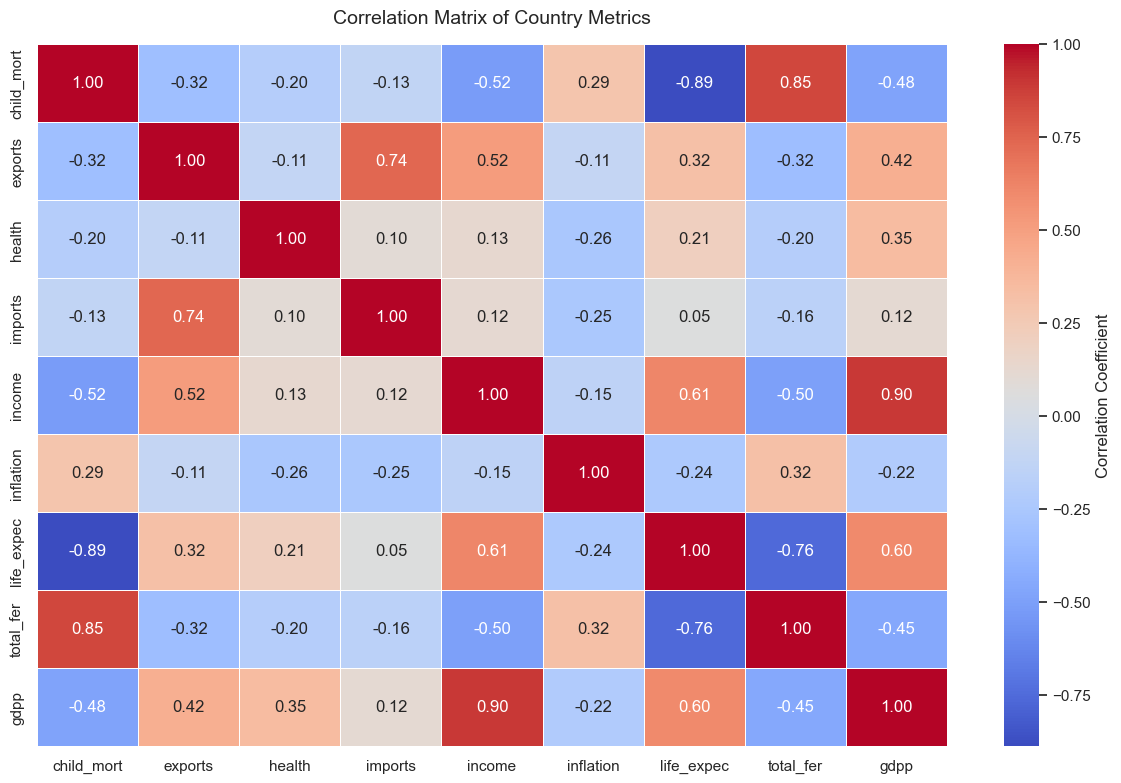

In [ ]:
# Visualize the relationships between features using a correlation heatmap
plt.figure(figsize=(12, 8))
# Select only numeric variables for correlation matrix calculation
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix of Country Metrics', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

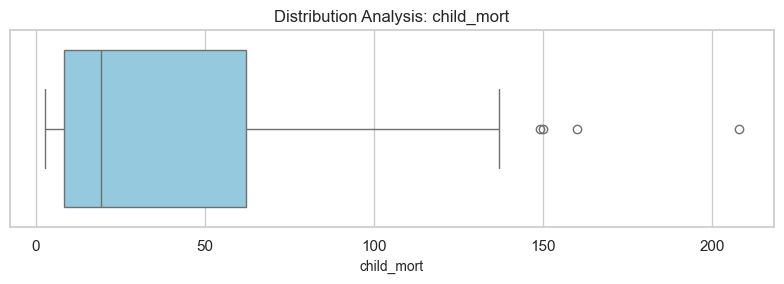

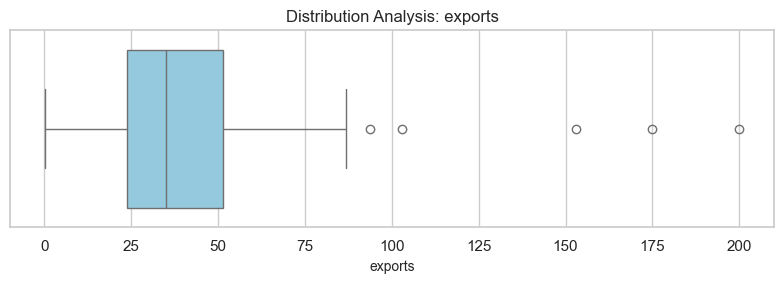

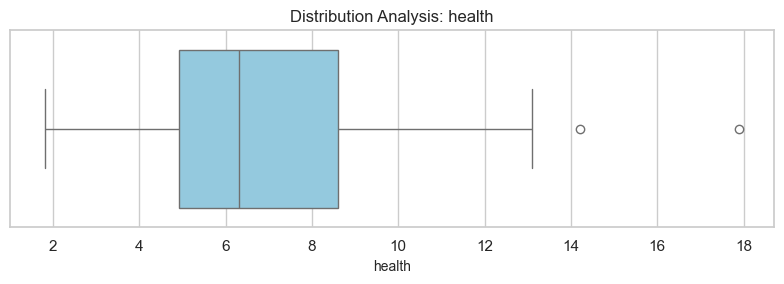

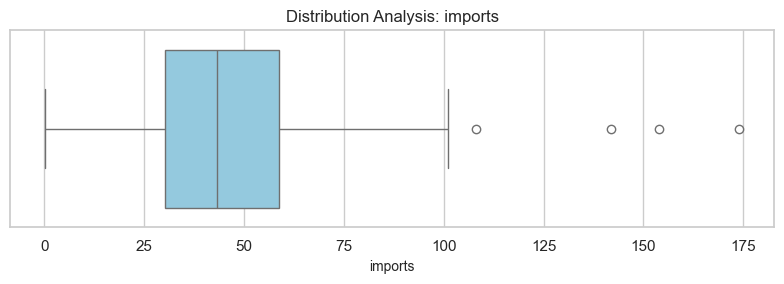

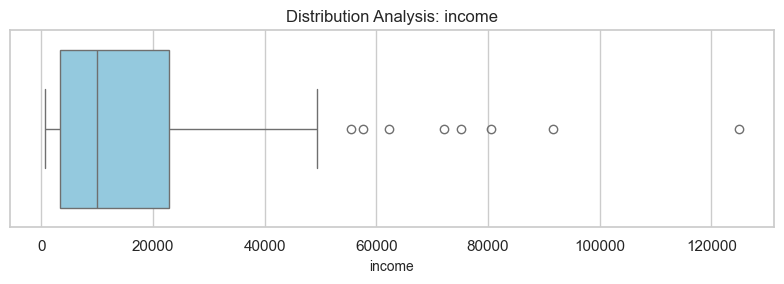

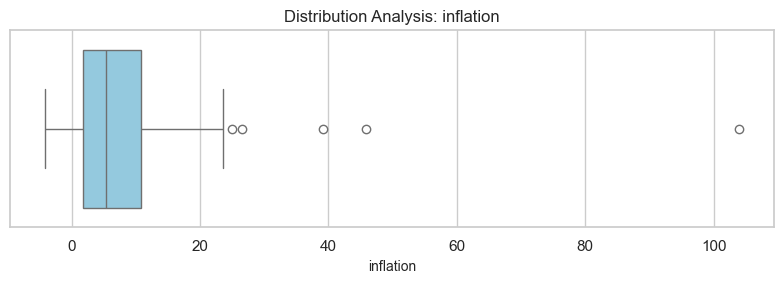

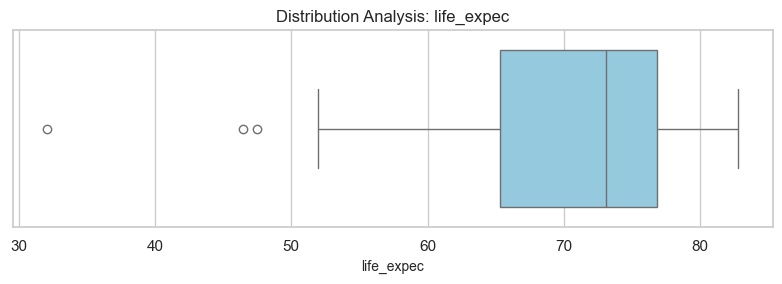

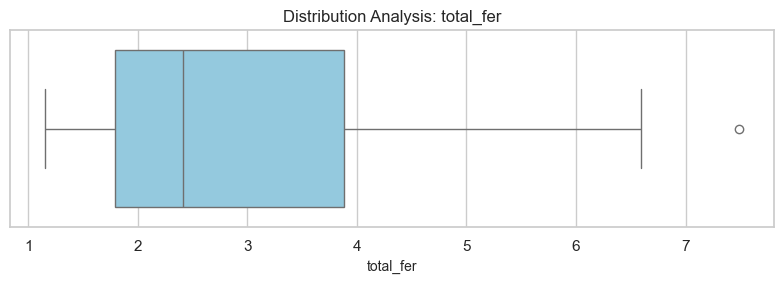

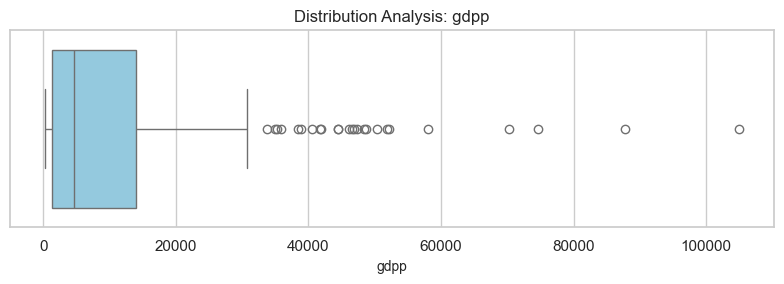

In [ ]:
# Examine distributions and outliers using boxplots for each numeric feature
for feature in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[feature], color='skyblue')
    plt.title(f'Distribution Analysis: {feature}', fontsize=12)
    plt.xlabel(feature, fontsize=10)
    plt.tight_layout()
    plt.show()

## 8) Feature scaling

Clustering works better when features are on the same scale.

In [ ]:
# Clean country string spaces before dropping
if 'country' in df.columns:
    df['country'] = df['country'].astype(str).str.strip()

# Exclude the string identifier 'country' to isolate continuous numerical features
features_data = df.drop(columns=['country'], errors='ignore')

# Scale the feature values using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_data)

# Print shape to verify scaling operation
print("Preprocessed feature matrix shape:", X_scaled.shape)

Preprocessed feature matrix shape: (167, 9)


## 9) K-Means: Elbow method

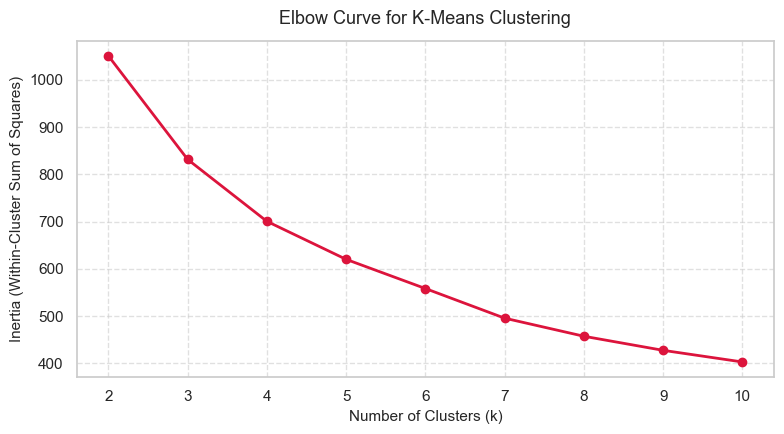

In [ ]:
# Run an optimization loop testing cluster counts k from 2 to 10
inertia_scores = []
k_range = range(2, 11)

for k in k_range:
    # Set random_state=42 for reproducibility
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    # Save the inertia score
    inertia_scores.append(kmeans_temp.inertia_)

# Plot the Elbow Curve to find the optimal cluster size
plt.figure(figsize=(8, 4.5))
plt.plot(list(k_range), inertia_scores, marker='o', color='crimson', linestyle='-', linewidth=2)
plt.title('Elbow Curve for K-Means Clustering', fontsize=13, pad=12)
plt.xlabel('Number of Clusters (k)', fontsize=11)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 10) Train K-Means

In [ ]:
# Define baseline cluster count based on elbow method evaluation
best_k = 3

# Initialize and fit the K-Means clustering model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans_final.fit_predict(X_scaled)

# Print silhouette score to evaluate clustering quality
silhouette = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f"K-Means (k={best_k}) Clustering Silhouette Score: {silhouette:.4f}")

# Display the first few cluster assignments
display(df[['country', 'kmeans_cluster']].head())

K-Means (k=3) Clustering Silhouette Score: 0.2833


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## 11) Try DBSCAN

In [ ]:
# Set up a density-based comparative clustering model (DBSCAN)
dbscan_model = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan_model.fit_predict(X_scaled)

# Check the distribution of assigned clusters (note: -1 indicates noise points)
print("DBSCAN Cluster Assignment Frequencies:")
print(df['dbscan_cluster'].value_counts().sort_index())

DBSCAN Cluster Assignment Frequencies:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


## 12) PCA visualization

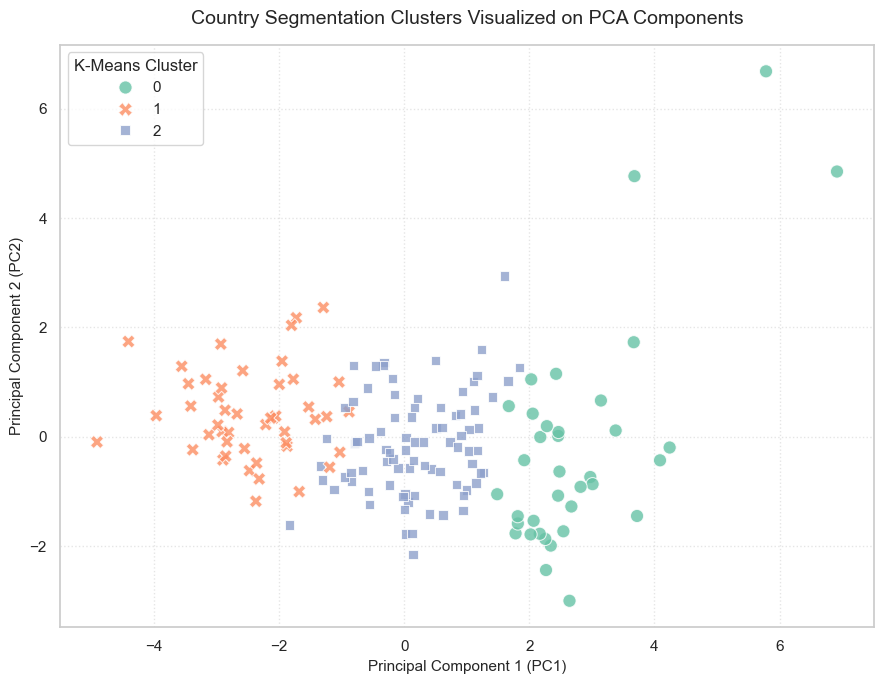

In [ ]:
# Project the high-dimensional scaled features into 2D using PCA
pca_model = PCA(n_components=2, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

# Build a dataframe containing the 2D coordinates and K-Means clusters
pca_dataframe = pd.DataFrame({
    'Principal Component 1': X_pca[:, 0],
    'Principal Component 2': X_pca[:, 1],
    'K-Means Cluster': df['kmeans_cluster']
})

# Draw a color-coded scatter plot of the clusters in PCA space
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=pca_dataframe,
    x='Principal Component 1',
    y='Principal Component 2',
    hue='K-Means Cluster',
    style='K-Means Cluster',
    palette='Set2',
    s=90,
    alpha=0.8
)
plt.title('Country Segmentation Clusters Visualized on PCA Components', fontsize=14, pad=15)
plt.xlabel('Principal Component 1 (PC1)', fontsize=11)
plt.ylabel('Principal Component 2 (PC2)', fontsize=11)
plt.legend(title='K-Means Cluster', loc='best')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 13) Cluster profiling

In [ ]:
# Group the dataset by K-Means clusters and compute the average for each numeric metric
segment_profiles = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)

# Display the resulting profiles to identify cluster characteristics
display(segment_profiles.T)

kmeans_cluster,0,1,2
child_mort,5.00,92.96,21.93
exports,58.74,29.15,40.24
health,8.81,6.39,6.20
imports,51.49,42.32,47.47
income,45672.22,3942.40,12305.60
inflation,2.67,12.02,7.60
life_expec,80.13,59.19,72.81
total_fer,1.75,5.01,2.31
gdpp,42494.44,1922.38,6486.45


## 14) Final insights

Based on the profiles of the clusters generated by the K-Means algorithm, we can make the following key observations:

1. **High-Mortality and Low-Development Zone (Cluster 1)**: This cluster of countries represents the most vulnerable regions globally. It features a shockingly high average child mortality rate of approximately **93 deaths per 1,000 live births** and a low life expectancy averaging only **59 years**. Economically, these nations are severely constrained, with an average annual income of **$3,942** and a GDP per capita of **$1,922**. Healthcare resources and infrastructure are clearly lacking in these countries.
2. **Top-Tier Economic Zones / Highly Developed Countries (Cluster 0)**: In stark contrast, Cluster 0 represents the wealthiest and most developed countries. Here, the average GDP per capita sits at a robust **$42,494**, and net income averages **$45,672** per year. These strong economic foundations translate to excellent health and quality-of-life metrics: average child mortality is extremely low at **5 deaths per 1,000 live births**, and average life expectancy reaches **80 years**.
3. **Developing/Middle-Tier Nations (Cluster 2)**: Cluster 2 functions as a transitional segment. Countries in this group demonstrate moderate development metrics, with an average child mortality rate of **22 deaths per 1,000 live births**, a healthy average life expectancy of **73 years**, and moderate income levels averaging **$12,306** per year.
4. **Aid Prioritization Strategy**: From a policymaking perspective, countries classified under **Cluster 1** must be prioritized for humanitarian aid, healthcare interventions, and development programs. The severe disparity in child mortality and life expectancy highlights that investments in sanitation, vaccines, and basic economic stability are desperately needed in these low-development areas.
